In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import matplotlib.pyplot as plt
import ants
import qmri_greps as qmri 

In [ ]:
# system cube for phantom data

# sequence parameters 
tr=13.5     # repetition time in ms
fa=20.0     # flip angle in degree
# phase increments in degree, which needs to match the phase increments used in the GREPS acquisition (4th dimension of nii files)
PhaInc     = np.array([1.0, 1.5, 2.0, 3.0, 4.0, 5.0])

# grid for system cube calculation
T2_grid    = np.linspace(1,200,200)
T1_over_T2 = np.linspace(1,30,100)
fa_grid    = np.linspace(14,26,40)

# => dimensions of system cube: 2*len(PhaInc), len(T2_grid), len(T1_over_T2), len(fa_grid)
# ( real and imaginary part of the complex signal in first dimension => 2*len(PhaInc) )

sc = qmri.system_cube('syscube_phantom_data.npz')  # loads system cube data from file, if it exists
if not os.path.isfile('syscube_phantom_data.npz'): # if not, calculate it (~12 min on MacStudio with 16 cores)
    nprocs = 16
    sc.calculate(nprocs,T2_grid,T1_over_T2,fa_grid,PhaInc,tr,VERBOSE=True)
print(sc)

system cube file: syscube_phantom_data.npz
 system cube shape = (12, 200, 100, 40)
 Phinc =[1.  1.5 2.  3.  4.  5. ]
 T2_grid    (min,max,#): (1,200,200)
 T1_over_T2 (min,max,#): (1,30,100)
 FA         (min,max,#): (14,26,40)


In [ ]:
# Phantom data example (data from Difei's paper)
magn_file= 'example_phantom_data/03_magnitude_2s.nii.gz'   # 4D nii file with magnitude data (4th dimension corresponds to different phase increments)
phas_file= 'example_phantom_data/04_phase_2s.nii.gz'       # 4D nii file with phase data (4th dimension corresponds to different phase increments)
mask_file= 'example_phantom_data/my_mask.nii.gz'           # binary mask nii file (same dimensions as magnitude/phase data, but only one 3D volume) defining the voxels to be fitted
b1_file  = 'example_phantom_data/02_B1_map_2s.nii.gz'      # B1 map nii file (same dimensions as magnitude/phase data, but only one 3D volume) with B1 values in percent (e.g. 100 means 100% of nominal flip angle, 110 means 110% of nominal flip angle, etc.)

# ~2 min on MS with 16 cores and system_cube interpolation
nprocs=8
qmri.param_fit(nprocs, magn_file, phas_file, mask_file, b1_file, tr, fa, PhaInc, sc,outputpath='example_phantom_data', outputbasename='phantom')

system cube file: syscube_phantom_data.npz
 system cube shape = (12, 200, 100, 40)
 Phinc =[1.  1.5 2.  3.  4.  5. ]
 T2_grid    (min,max,#): (1,200,200)
 T1_over_T2 (min,max,#): (1,30,100)
 FA         (min,max,#): (14,26,40)
num voxels= 17875
progress:  100  /  17875
progress:  200  /  17875
progress:  300  /  17875
progress:  400  /  17875
progress:  500  /  17875
progress:  600  /  17875
progress:  progress:  800  /  17875
700  /  17875
progress:  900  /  17875
progress:  1000  /  17875
progress:  1100  /  17875
progress:  1200  /  17875
progress:  1400  /  17875
progress:  1300  /  17875
progress:  1500  /  17875
progress:  1600  /  17875
progress:  1700  /  17875
progress:  1800  /  17875
progress:  1900  /  17875
progress:  2000  /  17875
progress:  2100  /  17875
progress:  2200  /  17875
progress:  2300  /  17875
progress:  2400  /  17875
progress:  2500  /  17875
progress:  2600  /  17875
progress:  2700  /  progress:  3200  /  17875
17875
progress:  2800  /  17875
progress:  

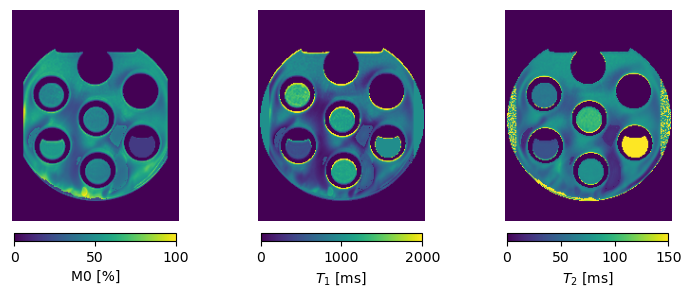

In [4]:
# plot phantom parameter maps
fig,ax=plt.subplots(1,3)
files=['example_phantom_data/Am_phantom.nii.gz','example_phantom_data/T1_phantom.nii.gz','example_phantom_data/T2_phantom.nii.gz']
VMAX=[100,2000,150]
LBL =['M0 [%]','$T_1$ [ms]','$T_2$ [ms]']
for i,file in enumerate(files):
    a_map=ants.image_read(filename=file)
    map=np.squeeze(a_map.numpy()[:,:,:])
    if i==0: map = 100*map/np.max(map)
    im = ax[i].imshow(map,vmax=VMAX[i])
    ax[i].set_axis_off()
    cm=fig.colorbar(im, ax=ax[i], fraction=0.035, pad=0.05, orientation='horizontal')
    cm.set_label(LBL[i])
fig.set_size_inches((9,3))
plt.show()


In [5]:
# in vivo data example
# data with many phase increments from my ISMRM abstract: https://cds.ismrm.org/protected/23MProceedings/PDFfiles/2628_WJpliQPnN.html

#sequence parameters 
tr=9.5
fa=20.0
PhaInc=np.array([-20, -15, -11, -8, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 8, 11, 15, 20])

nprocs = 8
sc = qmri.system_cube('system_cube_iv.npz')
if not os.path.isfile('system_cube_iv.npz'):  # if not, calculate it (takes ~60 min on MS with 16 cores)
    sc.calculate(nprocs,T2_grid,T1_over_T2,fa_grid,PhaInc,tr,VERBOSE=True)

magn_file= 'example_invivo_data/preproc_magn_2s.nii.gz' 
phas_file= 'example_invivo_data/preproc_phas_2s.nii.gz' 
mask_file= 'example_invivo_data/binary_mask_2s.nii.gz' 
b1_file  = 'example_invivo_data/corrected_B1_map_res_2s.nii.gz' 

# ~2 min on MS with 16 cores and system_cube interpolation !
qmri.param_fit(nprocs, magn_file, phas_file, mask_file, b1_file, tr, fa, PhaInc, sc, outputpath='example_invivo_data', outputbasename='iv')

system cube file: system_cube_iv.npz
 system cube shape = (40, 250, 117, 49)
 Phinc =[-20 -15 -11  -8  -6  -5  -4  -3  -2  -1   1   2   3   4   5   6   8  11
  15  20]
 T2_grid    (min,max,#): (1,250,250)
 T1_over_T2 (min,max,#): (1,30,117)
 FA         (min,max,#): (14,26,49)
num voxels= 8200
system cube file: system_cube_iv.npz
 system cube shape = (40, 250, 117, 49)
 Phinc =[-20 -15 -11  -8  -6  -5  -4  -3  -2  -1   1   2   3   4   5   6   8  11
  15  20]
 T2_grid    (min,max,#): (1,250,250)
 T1_over_T2 (min,max,#): (1,30,117)
 FA         (min,max,#): (14,26,49)
num voxels= 8200
progress:  100  /  8200
system cube file: system_cube_iv.npz
 system cube shape = (40, 250, 117, 49)
 Phinc =[-20 -15 -11  -8  -6  -5  -4  -3  -2  -1   1   2   3   4   5   6   8  11
  15  20]
 T2_grid    (min,max,#): (1,250,250)
 T1_over_T2 (min,max,#): (1,30,117)
 FA         (min,max,#): (14,26,49)
num voxels= 8200
progress:  200  /  8200
system cube file: system_cube_iv.npz
 system cube shape = (40, 250, 11

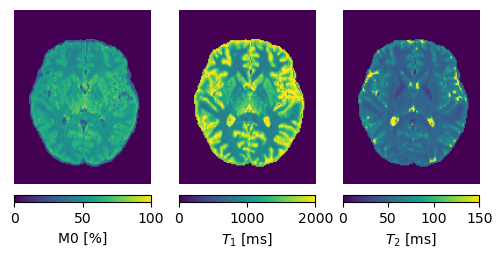

In [6]:
fig,ax=plt.subplots(1,3)
files=['example_invivo_data/Am_iv.nii.gz','example_invivo_data/T1_iv.nii.gz','example_invivo_data/T2_iv.nii.gz']
VMAX=[100,2000,150]
LBL =['M0 [%]','$T_1$ [ms]','$T_2$ [ms]']
for i,file in enumerate(files):
    a_map=ants.image_read(filename=file)
    map=np.squeeze(a_map.numpy()[:,:,:])
    if i==0: map = 100*map/np.max(map)
    im = ax[i].imshow(np.flipud(map.T),vmax=VMAX[i])
    ax[i].set_axis_off()
    #ax[i].set_title(file.replace('_ts.nii.gz','').replace('tmp/',''))
    cm=fig.colorbar(im, ax=ax[i], fraction=0.035, pad=0.05, orientation='horizontal')
    cm.set_label(LBL[i])
fig.set_size_inches((6,3))
plt.show()


fit:  793.2962790722725 45.33870526710481 6954.636573420957


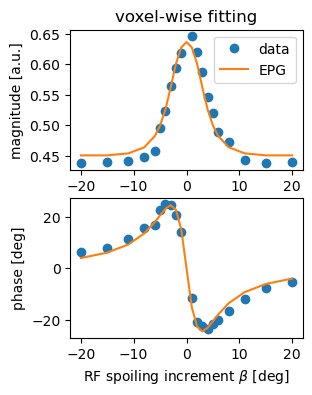

In [10]:
# Fitting example for one voxel (voxel-wise fitting, not using system cube interpolation, just to show the fit quality for one voxel)

from scipy.optimize import least_squares

n=293 # voxel index (in the masked area) for which to show the fit
(complex_signal, mask, fa_mask, d_phi) = qmri.load_data(magn_file, phas_file, mask_file, b1_file, fa, PhaInc)
cs = complex_signal[:,n]

# LSQ fit
x0   = [1000.0, 80.0, 15000]            #lsq start values  for T1, T2, and amplitude scaling
bnds = ([1, 1, 1],[10000, 1000, 50000]) #lsq search bounds for T1, T2, and amplitude scaling
fa = fa_mask[n]
args = (fa,tr,PhaInc,cs)  
res = least_squares(qmri.greps_diff_signal_err_least_squares, x0, args=args, bounds=bnds, ftol = 1e-10, xtol = 1e-10, gtol = 1e-10)

t1 = res.x[0] # fitted T1 value
t2 = res.x[1] # fitted T2 value
am = res.x[2] # fitted amplitude scaling factor 

print('fit: ',t1,t2,am)

# calculate GREPS signal for fitted T1 and T2 values 
PhaIncWithZero = np.insert(PhaInc, len(PhaInc)//2, 0) # insert zero phase increment in center of PhaInc array 
gs = np.zeros((len(PhaIncWithZero),),dtype=complex)

for i in range(len(PhaIncWithZero)):
    a,p    = qmri.greps_signal_pyepg(t1, t2, fa, PhaIncWithZero[i], tr)
    gs[i] = am * a * np.exp(-1.0j * p)

#plot fit results
fig,ax=plt.subplots(2,1)
ax[0].plot(PhaInc,np.abs(cs)/1000,'o',label='data')
ax[0].plot(PhaIncWithZero,np.abs(gs)/1000 ,label='EPG')
ax[0].set_ylabel(r'magnitude [a.u.]')
ax[0].legend()
ax[0].set_title('voxel-wise fitting')
ax[1].plot(PhaInc,np.rad2deg(np.angle(cs)),'o')
ax[1].plot(PhaIncWithZero,np.rad2deg(np.angle(gs)))
ax[1].set_xlabel(r'RF spoiling increment $\beta$ [deg]')
ax[1].set_ylabel(r'phase [deg]')
fig.set_size_inches((3,4))
plt.show()